In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


In [17]:
df = pd.read_csv("dataset_heart.csv")
df.head()


,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1


In [ ]:
#Exercice 1 
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest pain type                       270 non-null    int64  
 3   resting blood pressure                270 non-null    int64  
 4   serum cholestoral                     270 non-null    int64  
 5   fasting blood sugar                   270 non-null    int64  
 6   resting electrocardiographic results  270 non-null    int64  
 7   max heart rate                        270 non-null    int64  
 8   exercise induced angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  ST segment                            270 non-null    int64  
 11  major vessels      

age                                     0
sex                                     0
chest pain type                         0
resting blood pressure                  0
serum cholestoral                       0
fasting blood sugar                     0
resting electrocardiographic results    0
max heart rate                          0
exercise induced angina                 0
oldpeak                                 0
ST segment                              0
major vessels                           0
thal                                    0
heart disease                           0
dtype: int64

In [ ]:

X = df.drop('heart disease', axis=1)
y = df['heart disease']

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (270, 13)
Target shape: (270,)


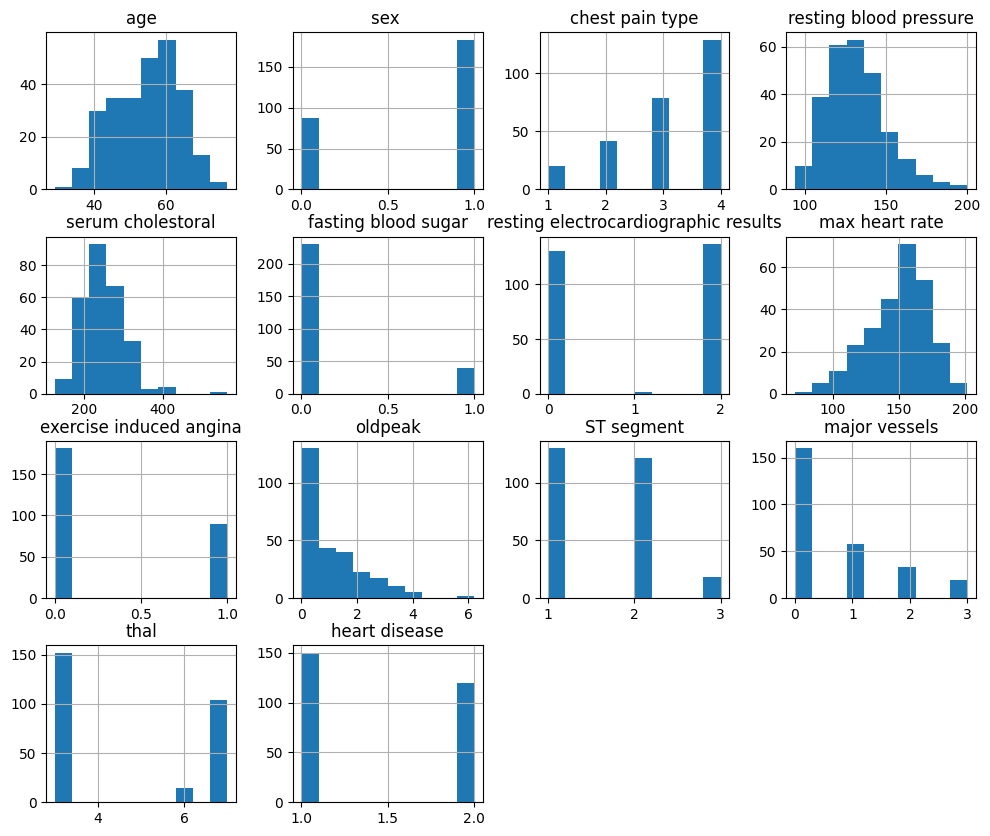

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

df.hist(figsize=(12,10))
plt.show()


In [9]:
#Exercise 2: Logistic Regression (Without Grid Search)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.8518518518518519
              precision    recall  f1-score   support

           1       0.92      0.80      0.86        30
           2       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54

[[24  6]
 [ 2 22]]


c:\Users\asus\Desktop\GenAI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
#Exercise 3: Logistic Regression (With Grid Search)
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_lr.fit(X_train, y_train)

print("Best Parameters:", grid_lr.best_params_)

y_pred = grid_lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Accuracy: 0.8518518518518519


In [12]:
#Exercise 4: SVM (Without Grid Search)
from sklearn.svm import SVC

model_svm = SVC(kernel='rbf', C=1, gamma='scale')
model_svm.fit(X_train, y_train)

y_pred = model_svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7407407407407407
              precision    recall  f1-score   support

           1       0.72      0.87      0.79        30
           2       0.78      0.58      0.67        24

    accuracy                           0.74        54
   macro avg       0.75      0.73      0.73        54
weighted avg       0.75      0.74      0.73        54



In [13]:
#Exercise 5: SVM (With Grid Search)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 0.01, 0.1, 1]
}

grid_svm = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_svm.fit(X_train, y_train)

print("Best Parameters:", grid_svm.best_params_)

y_pred = grid_svm.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy: 0.8518518518518519


In [23]:
#Exercise 6: XGBoost (Without Grid Search)
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

model_xgb = XGBClassifier(
    learning_rate=0.1,
    n_estimators=100,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)

model_xgb.fit(X_train, y_train)

y_pred = model_xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



Accuracy: 0.7962962962962963
              precision    recall  f1-score   support

           0       0.85      0.77      0.81        30
           1       0.74      0.83      0.78        24

    accuracy                           0.80        54
   macro avg       0.80      0.80      0.80        54
weighted avg       0.80      0.80      0.80        54



In [24]:
#Exercise 7: XGBoost (With Grid Search)
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7]
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_xgb.fit(X_train, y_train)

print("Best Parameters:", grid_xgb.best_params_)

y_pred = grid_xgb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}
Accuracy: 0.8333333333333334


In [34]:
#Final Comparison (Recommended Section)
models = {
    "Logistic Regression": model_lr,
    "SVM": model_svm,
    "XGBoost": model_xgb
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"{name} Accuracy: {accuracy_score(y_test, y_pred)}")


Logistic Regression Accuracy: 0.037037037037037035
SVM Accuracy: 0.18518518518518517
XGBoost Accuracy: 0.7962962962962963


In [27]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset_heart.csv")

# Convert labels immediately
df['heart disease'] = df['heart disease'] - 1

print("Unique labels:", df['heart disease'].unique())


Unique labels: [1 0]


In [28]:
from sklearn.model_selection import train_test_split

X = df.drop('heart disease', axis=1)
y = df['heart disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=5000)
lr.fit(X_train_scaled, y_train)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr.predict(X_test_scaled)))


Logistic Regression Accuracy: 0.8518518518518519


In [32]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train_scaled, y_train)

print("SVM Accuracy:",
      accuracy_score(y_test, svm.predict(X_test_scaled)))


SVM Accuracy: 0.8148148148148148


In [33]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    learning_rate=0.1,
    n_estimators=100,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb.predict(X_test)))


XGBoost Accuracy: 0.7962962962962963
